<a href="https://colab.research.google.com/github/pranita30012005/ChronicDiseaseRiskAnalysis/blob/main/_Model_Evaluation_%26_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Chronic Disease Risk Factor Analysis
### Day 6 — Notebook 6: Model Evaluation & Tuning
**Goal:** Evaluate models properly (beyond accuracy), tune the top candidates,
and select a final model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, cross_val_score,
                                       GridSearchCV, RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
from google.colab import drive
drive.mount('/content/drive')

FEATURES_PATH = "/content/drive/MyDrive/ChronicDiseaseRiskAnalysis/data/processed/features_final.csv"
data = pd.read_csv(FEATURES_PATH)

# Print columns to identify the correct target variable
print("DataFrame columns:", data.columns.tolist())

X = data.drop(['survived', 'split'], axis=1) # Drop 'survived' and 'split' columns
y = data['survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'class_First', 'class_Second', 'class_Third', 'who_child', 'who_man', 'who_woman', 'adult_male_False', 'adult_male_True', 'alone_True', 'survived', 'split']
Features shape: (891, 19)
Target shape: (891,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 19)
Test shape: (179, 19)


In [15]:
models = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))]),
    "Decision Tree": Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))]),
    "XGBoost": Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(random_state=42, eval_metric='logloss'))]),
    "SVM": Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
    "Naive Bayes": Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())])
}

print("Models ready:", list(models.keys()))

Models ready: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM', 'KNN', 'Naive Bayes']


In [16]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

leaderboard = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
leaderboard

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.810056,0.807018,0.666667,0.730159,0.830040
1,Decision Tree,0.798883,0.770492,0.681159,0.723077,0.775099
2,Logistic Regression,0.776536,0.763636,0.608696,0.677419,0.784453
3,KNN,0.776536,0.773585,0.594203,0.672131,0.784256
4,XGBoost,0.770950,0.750000,0.608696,0.672000,0.790777
5,Naive Bayes,0.743017,0.682540,0.623188,0.651515,0.788406
6,SVM,0.776536,0.853659,0.507246,0.636364,0.732806


Confusion Matrix — Random Forest
[[99 11]
 [23 46]]


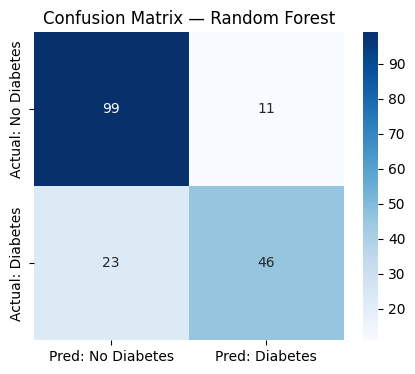

In [17]:
best_model_name = leaderboard.iloc[0]['Model']
best_pipeline = models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
print(f"Confusion Matrix — {best_model_name}")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Diabetes', 'Pred: Diabetes'],
            yticklabels=['Actual: No Diabetes', 'Actual: Diabetes'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

In [18]:
print(classification_report(y_test, y_pred_best, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.81      0.90      0.85       110
    Diabetes       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



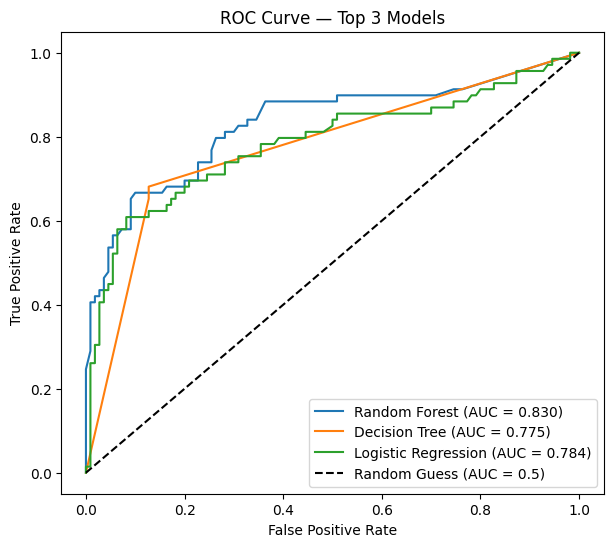

In [19]:
plt.figure(figsize=(7, 6))
top_3 = leaderboard.head(3)['Model'].tolist()

for name in top_3:
    y_proba = models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Top 3 Models')
plt.legend()
plt.show()

In [20]:
for name in top_3:
    cv_scores = cross_val_score(models[name], X, y, cv=5, scoring='f1')
    print(f"{name}: CV F1 = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Random Forest: CV F1 = 0.757 (+/- 0.029)
Decision Tree: CV F1 = 0.718 (+/- 0.025)
Logistic Regression: CV F1 = 0.761 (+/- 0.021)


In [21]:
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))])

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8, None],
    'clf__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 3))

Best parameters: {'clf__max_depth': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV F1 score: 0.777


In [22]:
from scipy.stats import uniform

svm_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))])

param_dist = {
    'clf__C': uniform(0.1, 10),
    'clf__gamma': ['scale', 'auto'],
    'clf__kernel': ['rbf', 'linear']
}

random_search = RandomizedSearchCV(svm_pipeline, param_dist, n_iter=20, cv=5,
                                     scoring='f1', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV F1 score:", round(random_search.best_score_, 3))

Best parameters: {'clf__C': np.float64(0.30584494295802445), 'clf__gamma': 'auto', 'clf__kernel': 'linear'}
Best CV F1 score: 0.774


In [23]:
tuned_rf = grid_search.best_estimator_
tuned_svm = random_search.best_estimator_

for name, model in [("Tuned Random Forest", tuned_rf), ("Tuned SVM", tuned_svm)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"{name}: Accuracy={accuracy_score(y_test, y_pred):.3f}, "
          f"F1={f1_score(y_test, y_pred):.3f}, ROC-AUC={roc_auc_score(y_test, y_proba):.3f}")

Tuned Random Forest: Accuracy=0.788, F1=0.689, ROC-AUC=0.791
Tuned SVM: Accuracy=0.788, F1=0.689, ROC-AUC=0.742


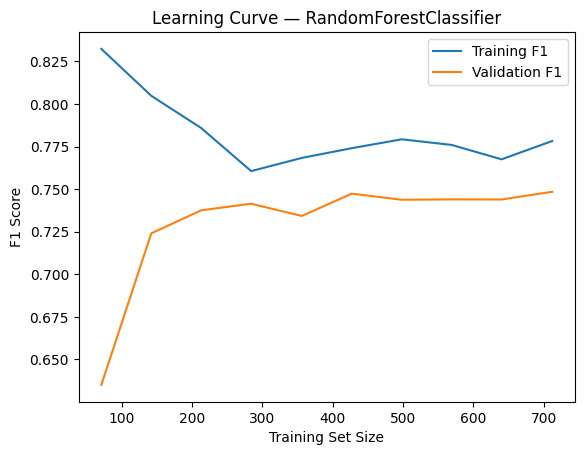

In [24]:
final_model = tuned_rf  # swap this if a different model won in Cell 13

train_sizes, train_scores, val_scores = learning_curve(
    final_model, X, y, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title(f'Learning Curve — {type(final_model.named_steps["clf"]).__name__}')
plt.legend()
plt.show()

In [26]:
import os

MODEL_PATH = "/content/drive/MyDrive/ChronicDiseaseRiskAnalysis/reports/final_model.pkl"

# Ensure the directory exists before saving the model
output_dir = os.path.dirname(MODEL_PATH)
os.makedirs(output_dir, exist_ok=True)

joblib.dump(final_model, MODEL_PATH)

print("Final model saved to:", MODEL_PATH)

Final model saved to: /content/drive/MyDrive/ChronicDiseaseRiskAnalysis/reports/final_model.pkl


## 📝 Day 6 Observations

- Best baseline model (by F1): ___
- Winning tuned model and its best parameters: ___
- Recall of my final model on the "Diabetes" class: ___
- Does my learning curve suggest overfitting, underfitting, or a good balance? ___
- If I had more time, one thing I'd try to improve recall: ___